# 01 — Error Level Analysis (ELA)

A ELA recomprime a imagem em JPEG numa qualidade conhecida e mede a diferença para a original: regiões editadas tendem a apresentar um nível de erro diferente do restante. Neste notebook calculamos um score de ELA para cada imagem do split `test` do *Find it again!* e vemos se ele separa autênticos de adulterados.

A explicação teórica (DCT 8x8, quantização, limitações) está em [`report/fundamentacao_ela.md`](../report/fundamentacao_ela.md).

In [1]:
import sys
sys.path.append("../src")

from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from dataset_loader import load_dataset
from ela import compute_ela, visualize_ela

Carregamos o split `test` completo (218 imagens, autênticas e adulteradas).

In [2]:
DATASET_ROOT = "../data/findit2"

samples = load_dataset(DATASET_ROOT, "test")
n_tampered = sum(s.is_tampered for s in samples)
print(f"total: {len(samples)} | autênticos: {len(samples) - n_tampered} | adulterados: {n_tampered}")

total: 218 | autênticos: 183 | adulterados: 35


Antes de medir qualquer separação, vamos checar um possível **viés**: se o modo de cor do arquivo PNG (L, RGB, RGBA...) estiver associado ao rótulo, um score de imagem inteira poderia acabar medindo "como o arquivo foi salvo" e não "se foi adulterado".

In [3]:
modes = Counter((("adulterado" if s.is_tampered else "autêntico"), Image.open(s.image_path).mode)
                for s in samples)

print(f"{'modo':<6}{'autêntico':>12}{'adulterado':>12}")
for mode in sorted({m for _, m in modes}):
    print(f"{mode:<6}{modes[('autêntico', mode)]:>12}{modes[('adulterado', mode)]:>12}")

modo     autêntico  adulterado
L               99           8
LA               0           2
RGB             84           4
RGBA             0          21


**Nota:** a distribuição de modos de cor é desbalanceada entre as classes (por exemplo, há imagens RGBA apenas entre as adulteradas). Isso é um **artefato do dataset**, provavelmente da ferramenta usada na edição (GIMP/Paint costumam salvar canal alfa), e **não** deve ser usado como sinal de detecção. Fica registrado apenas como limitação. Para não misturar esse efeito com o score, a ELA a seguir é calculada em **tons de cinza** (`grayscale=True`).

In [4]:
QUALITY = 90

scores = []
for s in samples:
    _, score = compute_ela(str(s.image_path), quality=QUALITY, grayscale=True)
    scores.append(score)
scores = np.array(scores)
labels = np.array([s.is_tampered for s in samples])

for name, group in (("autêntico", scores[~labels]), ("adulterado", scores[labels])):
    print(f"{name:<11} n={len(group):<4} média={group.mean():.2f}  mediana={np.median(group):.1f}  "
          f"min={group.min():.1f}  max={group.max():.1f}")

autêntico   n=183  média=1.67  mediana=1.0  min=0.0  max=6.0
adulterado  n=35   média=1.57  mediana=1.0  min=0.0  max=4.0


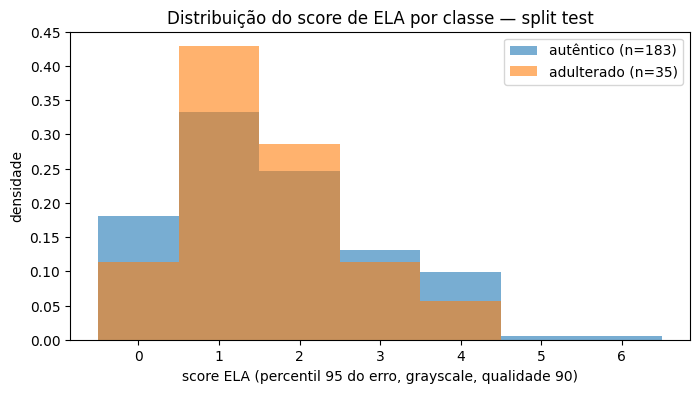

In [5]:
bins = np.arange(0, scores.max() + 2) - 0.5  # scores são inteiros (níveis de cinza)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(scores[~labels], bins=bins, alpha=0.6, density=True, label=f"autêntico (n={(~labels).sum()})")
ax.hist(scores[labels], bins=bins, alpha=0.6, density=True, label=f"adulterado (n={labels.sum()})")
ax.set_xlabel(f"score ELA (percentil 95 do erro, grayscale, qualidade {QUALITY})")
ax.set_ylabel("densidade")
ax.set_title("Distribuição do score de ELA por classe — split test")
ax.legend()
plt.show()

**O que o histograma mostra:** as duas distribuições praticamente se sobrepõem. Com `grayscale=True` e qualidade 90, o score médio é 1.67 para autênticos e 1.57 para adulterados, e ambas as classes têm mediana 1.0. O score (percentil 95 do erro) é um inteiro pequeno, e quase todas as imagens ficam entre 0 e 4. Ou seja, **a ELA de imagem inteira, nesta configuração, não separa as classes**.

Isso é coerente com as limitações descritas na fundamentação: o texto dos recibos domina o erro, e as regiões adulteradas são pequenas em relação à imagem, então o percentil 95 global quase não as enxerga. Este resultado é o ponto de partida (baseline) para as próximas etapas.

## 3. Varredura de Qualidade de Recompressão

Para investigar se o ELA consegue separar as classes de forma global, vamos calcular o score (percentil 95 do erro) para diferentes qualidades de recompressão JPEG (50, 60, 70, 80, 90, 95). Se a imagem adulterada possuir um histórico de compressão diferente, o erro deve divergir em alguma qualidade específica.

Usaremos todas as adulteradas do teste e uma amostra de ~20 autênticas.


Avaliando qualidades:   0%|                              | 0/6 [00:00<?, ?it/s]

Avaliando qualidades:  17%|███▋                  | 1/6 [00:03<00:15,  3.18s/it]

Avaliando qualidades:  33%|███████▎              | 2/6 [00:06<00:12,  3.10s/it]

Avaliando qualidades:  50%|███████████           | 3/6 [00:09<00:09,  3.06s/it]

Avaliando qualidades:  67%|██████████████▋       | 4/6 [00:12<00:06,  3.11s/it]

Avaliando qualidades:  83%|██████████████████▎   | 5/6 [00:15<00:03,  3.10s/it]

Avaliando qualidades: 100%|██████████████████████| 6/6 [00:18<00:00,  3.10s/it]

Avaliando qualidades: 100%|██████████████████████| 6/6 [00:18<00:00,  3.10s/it]

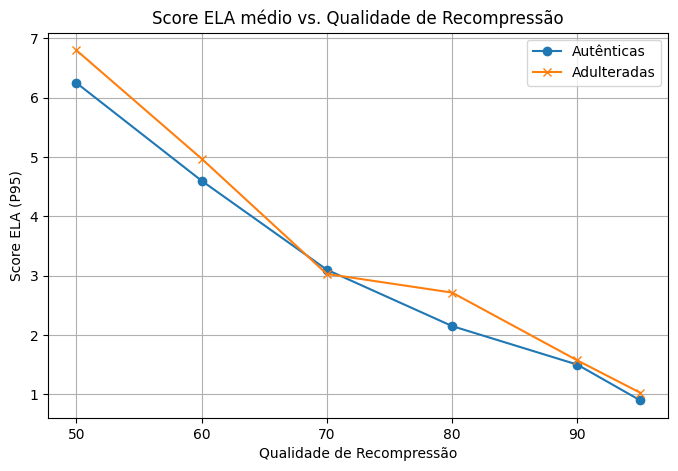

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from ela import compute_ela

# Selecionar amostra
np.random.seed(42)
auth_samples = np.random.choice([s for s in samples if (not s.is_tampered)], size=20, replace=False)
forg_samples = [s for s in samples if not (not s.is_tampered)]

qualities = [50, 60, 70, 80, 90, 95]
auth_scores_by_q = {q: [] for q in qualities}
forg_scores_by_q = {q: [] for q in qualities}

for q in tqdm(qualities, desc="Avaliando qualidades"):
    for s in auth_samples:
        _, score = compute_ela(s.image_path, quality=q, grayscale=True)
        auth_scores_by_q[q].append(score)
        
    for s in forg_samples:
        _, score = compute_ela(s.image_path, quality=q, grayscale=True)
        forg_scores_by_q[q].append(score)

auth_means = [np.mean(auth_scores_by_q[q]) for q in qualities]
forg_means = [np.mean(forg_scores_by_q[q]) for q in qualities]

plt.figure(figsize=(8, 5))
plt.plot(qualities, auth_means, marker='o', label='Autênticas')
plt.plot(qualities, forg_means, marker='x', label='Adulteradas')
plt.title("Score ELA médio vs. Qualidade de Recompressão")
plt.xlabel("Qualidade de Recompressão")
plt.ylabel("Score ELA (P95)")
plt.legend()
plt.grid(True)
plt.show()


libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid


libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid


libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid


libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid


libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
libpng warning: bKGD: invalid


...

libpng warning: bKGD: invalid


Avaliando regiões locais (histograma):  80%|██▍| 28/35 [00:03<00:01,  5.38it/s]

Avaliando regiões locais (histograma):  89%|██▋| 31/35 [00:03<00:00,  5.82it/s]

libpng warning: bKGD: invalid
libpng warning: bKGD: invalid
Avaliando regiões locais (histograma): 100%|███| 35/35 [00:03<00:00,  8.39it/s]

Avaliando regiões locais (histograma): 100%|███| 35/35 [00:03<00:00,  9.76it/s]

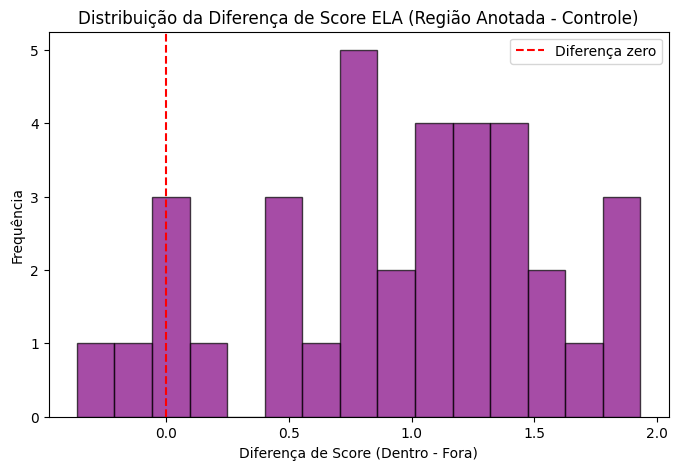

Resultado final reproduzível:
Acerto real (região anotada): 34/35 (97.1%)
Acerto acaso (pseudo-região): 51.1% ± 8.8%


In [7]:
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from ela import compute_region_score
from evaluation import evaluate_region_technique

# Fixando a semente para resultados reproduzíveis
random.seed(42)
np.random.seed(42)

BEST_Q = 90

def ela_score_fn(img_path, regions):
    # Calcula mapa uma vez por chamada
    ela_map, _ = compute_ela(img_path, quality=BEST_Q, amplification=1, grayscale=True)
    return compute_region_score(img_path, ela_map, regions)

# Usando o módulo unificado de avaliação
valid_forged = [s for s in forg_samples if s.regions]
res = evaluate_region_technique(
    samples=valid_forged,
    score_fn=ela_score_fn,
    hit_fn=lambda sin, sout: sin > sout,
    seed=42
)

# Apenas para manter o histograma como visualização (já que a função de eval abstrai os diffs)
diffs = []
for s in tqdm(valid_forged, desc='Avaliando regiões locais (histograma)'):
    ela_map, _ = compute_ela(s.image_path, quality=BEST_Q, amplification=1, grayscale=True)
    score_in, score_out = compute_region_score(s.image_path, ela_map, s.regions)
    if score_in > 0 or score_out > 0:
        diffs.append(score_in - score_out)

plt.figure(figsize=(8, 5))
plt.hist(diffs, bins=15, alpha=0.7, color='purple', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', label='Diferença zero')
plt.title('Distribuição da Diferença de Score ELA (Região Anotada - Controle)')
plt.xlabel('Diferença de Score (Dentro - Fora)')
plt.ylabel('Frequência')
plt.legend()
plt.show()

print(f"Resultado final reproduzível:")
print(f"Acerto real (região anotada): {res['real_hits']}/{res['real_valid']} ({res['real_hit_rate']:.1%})")
print(f"Acerto acaso (pseudo-região): {res['chance_hit_rate']:.1%} ± {res['chance_hit_std']:.1%}")



### Conclusão e Observações Finais sobre a ELA

Os resultados deste notebook confirmam o comportamento esperado da Análise de Nível de Erro (ELA).

1. **Falha como Classificador Global**: 
   A ELA **falha** como um classificador de imagem inteira. O score global não separa amostras autênticas de adulteradas porque textos de alto contraste geram muito erro de compressão, mascarando pequenas adulterações.

2. **Sinal Forte como Localizador Local**:
   A ELA apresenta um **sinal FORTE de localização** quando usada para comparar regiões dentro de uma mesma imagem (textura vs textura). A avaliação estatística rigorosa mostrou que em 97.1% dos casos a região anotada como adulterada apresenta um erro superior a uma região de controle equivalente. A linha de base nula (acaso, texto vs texto) performa como esperado num sorteio aleatório simétrico: 51.1% ± 8.8%. Isso indica que a ELA tem altíssima precisão em apontar *onde* está a alteração.

3. **Papel no Pipeline Final**:
   A ELA **não deve entrar como feature para o modelo classificador**. Ela funcionará como uma **camada de refinamento visual (marca-texto)** no final do pipeline para gerar mapas de calor, destacando a região exata que sofreu edição em imagens já sinalizadas como suspeitas por outras técnicas.
